In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import spikeinterface.preprocessing as spp
import spikeinterface.full as si
import xarray as xr
from spectral_connectivity import Connectivity, Multitaper

In [2]:
SMALL_SIZE = 20
MEDIUM_SIZE = 24
BIGGER_SIZE = 28
BIGGEST_SIZE = 38

plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=BIGGER_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)
plt.rc("figure", labelsize=BIGGEST_SIZE)

In [3]:
def xr_baseline_correction(data, baseline_segment):
    if not isinstance(baseline_segment, slice):
        baseline_segment = slice(baseline_segment[0], baseline_segment[1])
    baseline_data = data.sel(time=baseline_segment).copy()
    corrected_data = (
        (data - baseline_data.mean(dim="time")) / baseline_data.mean(dim="time")
    ) * 100
    return corrected_data

In [4]:
data_path = Path("/gpfs01/born/animal/DanielG/hypo_sleep/processed_data/")
full_dict = {
    "HYDO03": {
        "dates": ["2025-02-18_09-19-26", "2025-02-20_08-58-57"],
        "configs": ["2bbe", "2198"],  # ["c9a0", "2489"],  # ["ab39", "04d5"],
        "animal": "HYDO03",
        "data_path": data_path,
    },
    "HYDO04": {
        "dates": ["2025-02-24_09-00-29", "2025-02-26_09-05-08"],
        "configs": ["8374", "3295"],  # ["510e", "acb8"],  # ["f5d6", "507a"],
        "animal": "HYDO04",
        "data_path": data_path,
    },
}
triggers = [
    "spi-peak",
    "so-peak",
]
depth_ordered_chs = np.array(
    [
        "24",
        "23",
        "25",
        "22",
        "8",
        "7",
        "9",
        "6",
        "15",
        "0",
        "14",
        "1",
        "26",
        "21",
        "27",
        "20",
        "10",
        "5",
        "28",
        "19",
        "11",
        "4",
        "29",
        "18",
        "12",
        "3",
        "30",
        "17",
        "13",
        "2",
        "31",
        "16",
    ]
)

data_dict = {
    date: {trigger: {} for trigger in triggers}
    for date in [
        date for meta_dict in full_dict.values() for date in meta_dict["dates"]
    ]
}
trigger_ch = "39"
print("loading spectra")
for animal, meta_dict in full_dict.items():
    for date, config_id in zip(meta_dict["dates"], meta_dict["configs"]):
        tmp_output_path = Path(
            "/gpfs01/born/animal/DanielG/hypo_sleep/processed_data/",
            animal,
            date,
            config_id,
            "spectra",
        )
        for trigger, tmp_dict in data_dict[date].items():
            for region in ["ctx", "hyp"]:
                print(animal, date, trigger, region)
                load_path = Path(
                    tmp_output_path,
                    f"spectra_{trigger_ch}_{trigger}_meth-gsp_mtm_spectrogram_{region}_{config_id}.nc",
                )
                if load_path.exists():
                    tmp_da = xr.load_dataarray(load_path, engine="h5netcdf")
                    tmp_dict[region] = tmp_da.assign_coords(
                        time=("time", tmp_da.time.values.astype(np.float32))
                    )
                else:
                    tmp_dict[region] = None
                    print(f"File not found: {load_path}")
                    continue
animal_xr_dict = {
    animal: {
        trigger: {region: None for region in ["ctx", "hyp"]}
        for trigger in ["so-peak", "spi-peak"]
    }
    for animal in full_dict.keys()
}
for animal, animal_meta in full_dict.items():
    for trigger in ["so-peak", "spi-peak"]:  # , "nrem-null"]:
        for region in ["ctx", "hyp"]:
            min_time = min(
                [
                    data_dict[date][trigger][region].time.size
                    for date in animal_meta["dates"]
                ]
            )
            animal_xr_dict[animal][trigger][region] = [
                data_dict[date][trigger][region]
                .isel(time=slice(0, min_time))
                .mean(dim="trial")
                for date in animal_meta["dates"]
            ]

loading spectra
HYDO03 2025-02-18_09-19-26 spi-peak ctx


HYDO03 2025-02-18_09-19-26 spi-peak hyp
HYDO03 2025-02-18_09-19-26 so-peak ctx
HYDO03 2025-02-18_09-19-26 so-peak hyp
HYDO03 2025-02-20_08-58-57 spi-peak ctx
HYDO03 2025-02-20_08-58-57 spi-peak hyp
HYDO03 2025-02-20_08-58-57 so-peak ctx
HYDO03 2025-02-20_08-58-57 so-peak hyp
HYDO04 2025-02-24_09-00-29 spi-peak ctx
HYDO04 2025-02-24_09-00-29 spi-peak hyp
HYDO04 2025-02-24_09-00-29 so-peak ctx
HYDO04 2025-02-24_09-00-29 so-peak hyp
HYDO04 2025-02-26_09-05-08 spi-peak ctx
HYDO04 2025-02-26_09-05-08 spi-peak hyp
HYDO04 2025-02-26_09-05-08 so-peak ctx
HYDO04 2025-02-26_09-05-08 so-peak hyp


In [5]:
window = (
    3.501  # need 0.001 buffer to make sure we get the faull window with time slicing
)
animals = ["HYDO03", "HYDO04"]
spi_traces = {
    animal: {
        region: {filt_type: {} for filt_type in ["raw", "spi"]}
        for region in ["ctx", "hyp"]
    }
    for animal in animals
}  # nevents, ntimepoints, nchannels
so_traces = {
    animal: {
        region: {filt_type: {} for filt_type in ["raw", "so"]}
        for region in ["ctx", "hyp"]
    }
    for animal in animals
}  # nevents, ntimepoints, nchannels
rec_dict = {
    animal: {"ctx": {}, "hyp": {}} for animal in animals
}  # TODO: make this make sense
print("loading traces")
for animal, animal_meta in full_dict.items():
    for date, config_id in zip(animal_meta["dates"], animal_meta["configs"]):
        for region in rec_dict[animal].keys():
            for filt_type in ["raw", "so", "spi"]:
                if filt_type == "raw":
                    ref_id = (
                        "250_132b_ctx_global_fe80"
                        if region == "hyp"
                        else "250_132b_none_1da2"
                    )
                elif filt_type == "so":
                    ref_id = (
                        "ctx_global_fe80_so_3c1a"
                        if region == "hyp"
                        else "none_1da2_so_3c1a"
                    )
                elif filt_type == "spi":
                    ref_id = (
                        "ctx_global_fe80_spindle_a0a3"
                        if region == "hyp"
                        else "none_1da2_spindle_a0a3"
                    )
                # ref_id = "ctx_global_fe80_so_3c1a"  # if region == "hyp" else "none_1da2")
                rec_dir = list(
                    Path(data_path, animal, date, "rec", region).glob(ref_id)
                )[0]
                rec_dict[animal][region][filt_type] = si.load(rec_dir)
        so_df = pd.read_csv(
            Path(
                data_path,
                f"{animal}/{date}/{config_id}/slow_osc/so-df_ch-39_{config_id}.csv",
            )
        )
        spi_df = pd.read_csv(
            Path(
                data_path,
                f"{animal}/{date}/{config_id}/spindles/spindle_events_ch-39_{config_id}.csv",
            )
        )
        for region, reg_traces in so_traces[animal].items():
            for filt_type, traces in reg_traces.items():
                reg_rec = rec_dict[animal][region][filt_type]
                if reg_rec.has_channel_location():
                    reg_rec = si.depth_order(reg_rec)
                for ch in reg_rec.get_channel_ids():
                    ch_rec = reg_rec.select_channels(channel_ids=[ch])
                    if ch not in traces.keys():
                        traces[ch] = []
                    for _, row in so_df.iterrows():
                        tmp_rec = ch_rec.time_slice(
                            start_time=row.neg_peak_time - window,
                            end_time=row.neg_peak_time + window,
                            # start_time=row.down_crossing - window,
                            # end_time=row.down_crossing + window,
                        )
                        so_traces[animal][region][filt_type][ch].append(
                            tmp_rec.get_traces(return_scaled=True).flatten()[
                                : int(window * 2 * 250)
                            ]
                        )
        for region, reg_traces in spi_traces[animal].items():
            for filt_type, traces in reg_traces.items():
                reg_rec = rec_dict[animal][region][filt_type]
                if reg_rec.has_channel_location():
                    reg_rec = si.depth_order(reg_rec)
                for ch in reg_rec.get_channel_ids():
                    ch_rec = reg_rec.select_channels(channel_ids=[ch])
                    if ch not in traces.keys():
                        traces[ch] = []
                    for _, row in spi_df.iterrows():
                        tmp_rec = ch_rec.time_slice(
                            start_time=row.neg_peak - window,
                            end_time=row.neg_peak + window,
                            # start_time=row.down_crossing - window,
                            # end_time=row.down_crossing + window,
                        )
                        spi_traces[animal][region][filt_type][ch].append(
                            tmp_rec.get_traces(return_scaled=True).flatten()[
                                : int(window * 2 * 250)
                            ]
                        )
for animal, regions in spi_traces.items():
    for region, reg_traces in regions.items():
        for filt_type, traces in reg_traces.items():
            spi_traces[animal][region][filt_type] = {
                ch: np.stack(ch_traces) for ch, ch_traces in traces.items()
            }
for animal, regions in so_traces.items():
    for region, reg_traces in regions.items():
        for filt_type, traces in reg_traces.items():
            so_traces[animal][region][filt_type] = {
                ch: np.stack(ch_traces) for ch, ch_traces in traces.items()
            }

loading traces


In [7]:
stacked_traces = []
ch_list = []
# for animal, animal_traces in so_traces.items():
animal_traces = so_traces["HYDO04"]
for region, reg_traces in animal_traces.items():
    for ch, ch_traces in reg_traces["raw"].items():
        ch_list.append(ch)
        stacked_traces.append(ch_traces)
tmp_time = (
    np.arange(np.round(window, 2) * 2 * 250) - (np.round(window, 2) * 250)
) / 250

In [8]:
stack_xr_dict = {}
for trig, traces in zip(["so", "spi"], [so_traces["HYDO04"], spi_traces["HYDO04"]]):
    stacked_traces = []
    ch_list = []
    for region, reg_traces in traces.items():
        for ch, ch_traces in reg_traces["raw"].items():
            ch_list.append(ch)
            stacked_traces.append(ch_traces)
    tmp_time = (
        np.arange(np.round(window, 2) * 2 * 250) - (np.round(window, 2) * 250)
    ) / 250
    stacked_data = np.stack(stacked_traces, axis=-1).T
    stack_xr_dict[trig] = xr.DataArray(
        data=stacked_data,
        dims=["channel", "time", "trial"],
        coords={
            "channel": np.array(ch_list),
            "trial": np.arange(stacked_data.shape[-1]),
            "time": tmp_time,
        },
    )

In [9]:
rng = np.random.default_rng(37)
n_channels = 32
n_shuffles = 500
shuff_xr_dict = {}
for key, data in stack_xr_dict.items():
    stacked = data.isel(channel=slice(2, None)).mean(dim="trial")
    shuffled = np.empty(
        (n_channels, n_shuffles, data.time.values.size), dtype=np.float64
    )
    for j in range(n_channels):
        for i in range(n_shuffles):
            shuffled[j, i] = rng.permutation(stacked.isel(channel=j).values)
    tmp_da = xr.DataArray(
        data=shuffled,
        dims=["channel", "shuffle", "time"],
        coords={
            "channel": data.isel(channel=slice(2, None)).channel.values,
            "shuffle": np.arange(n_shuffles),
            "time": data.time.values,
        },
    )
    shuff_xr_dict[key] = xr.concat(
        [tmp_da, data.isel(channel=slice(None, 2)).mean(dim="trial")], dim="channel"
    )

coh_dict_shuff = {
    key: {"conn": [], "coherence": [], "phase": [], "frequency": []}
    for key in ["so", "spi"]
}
for key, val in shuff_xr_dict.items():
    for trial in val.trial.values:
        coh_dict_shuff[key] = {}
        mtm = Multitaper(
            val.sel(time=slice(-2.5, -1.5)).T,
            sampling_frequency=250,
            start_time=val.time.values[0],
        )
        connectivity = Connectivity.from_multitaper(mtm)
    coherence = connectivity.coherence_magnitude()
    coh_dict_shuff[key]["conn"].append(connectivity)
    coh_dict_shuff[key]["coherence"].append(connectivity.coherence_magnitude())
    coh_dict_shuff[key]["phase"].append(connectivity.coherence_phase())
    coh_dict_shuff[key]["frequency"].append(connectivity.frequencies)

AttributeError: 'DataArray' object has no attribute 'trial'

In [22]:
coh_dict = {
    key: {"conn": [], "coherence": [], "phase": [], "frequency": []}
    for key in ["so", "spi"]
}
coh_dict_null = {
    key: {"conn": [], "coherence": [], "phase": [], "frequency": []}
    for key in ["so", "spi"]
}
for key, val in stack_xr_dict.items():
    for trial in range(val.trial.values.size):
        mtm = Multitaper(
            val.sel(time=slice(-0.5, 0.5))
            .isel(trial=trial)
            .transpose("time", "channel"),
            sampling_frequency=250,
            start_time=val.time.values[0],
        )
        connectivity = Connectivity.from_multitaper(mtm)
        coherence = connectivity.coherence_magnitude()
        coh_dict[key]["conn"].append(connectivity)
        coh_dict[key]["coherence"].append(connectivity.coherence_magnitude())
        coh_dict[key]["phase"].append(connectivity.coherence_phase())
        coh_dict[key]["frequency"].append(connectivity.frequencies)
        mtm = Multitaper(
            val.sel(time=slice(-2.5, -1.5))
            .isel(trial=trial)
            .transpose("time", "channel"),
            sampling_frequency=250,
            start_time=val.time.values[0],
        )
        connectivity = Connectivity.from_multitaper(mtm)
        coherence = connectivity.coherence_magnitude()
        coh_dict_null[key]["conn"].append(connectivity)
        coh_dict_null[key]["coherence"].append(connectivity.coherence_magnitude())
        coh_dict_null[key]["phase"].append(connectivity.coherence_phase())
        coh_dict_null[key]["frequency"].append(connectivity.frequencies)

In [23]:
for (key1, val1), (key2, val2) in zip(coh_dict.items(), coh_dict_null.items()):
    coh_dict[key1]["coherence"] = np.stack(val1["coherence"], axis=0)
    coh_dict_null[key2]["coherence"] = np.stack(val2["coherence"], axis=0)
    coh_dict[key1]["phase"] = np.stack(val1["phase"], axis=0)
    coh_dict_null[key2]["phase"] = np.stack(val2["phase"], axis=0)
    coh_dict[key1]["frequency"] = np.stack(val1["frequency"], axis=0)
    coh_dict_null[key2]["frequency"] = np.stack(val2["frequency"], axis=0)

/tmp/ipykernel_3294838/3690321257.py:2: RuntimeWarning: Mean of empty slice
  ax.plot(np.nanmean(coh_dict["spi"]["coherence"], axis=0)[0, :51, 0, -1])
/tmp/ipykernel_3294838/3690321257.py:3: RuntimeWarning: Mean of empty slice
  ax.plot(np.nanmean(coh_dict_null["spi"]["coherence"], axis=0)[0, :51, 0, -1])


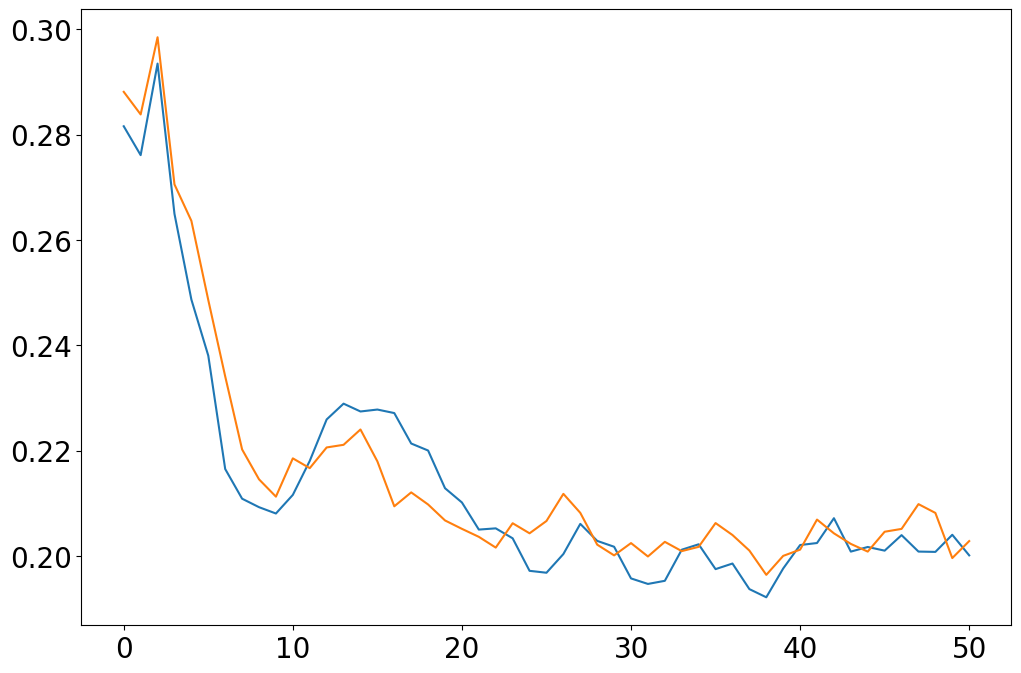

In [80]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(np.nanmean(coh_dict["spi"]["coherence"], axis=0)[0, :51, 0, -1])
ax.plot(np.nanmean(coh_dict_null["spi"]["coherence"], axis=0)[0, :51, 0, -1])

(<a list of 4 Line2D ticklines objects>,
 [Text(0.0, 0, '0°'), Text(1.5707963267948966, 0, '90°')])

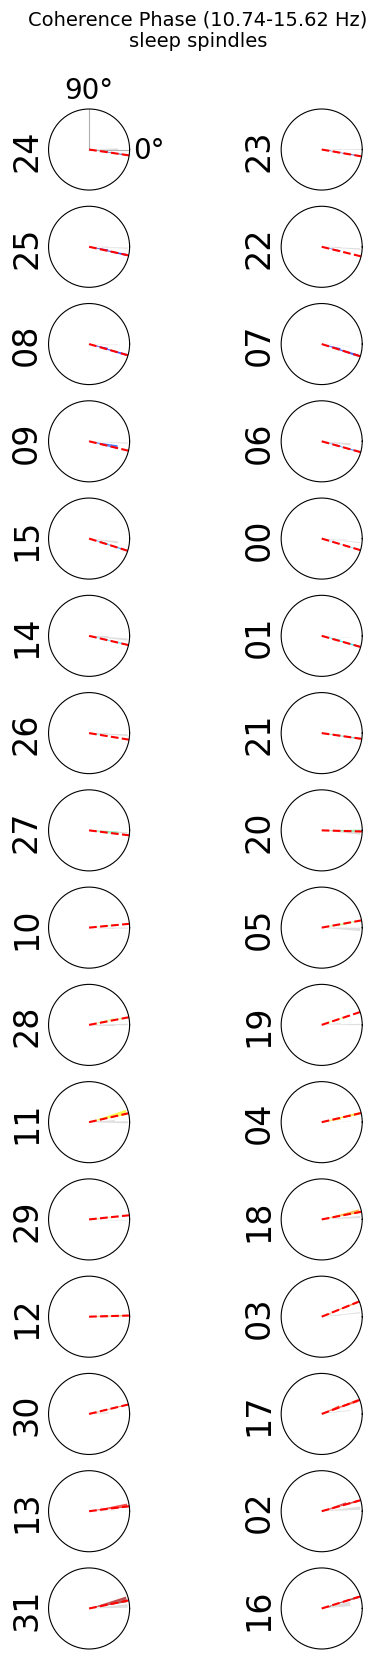

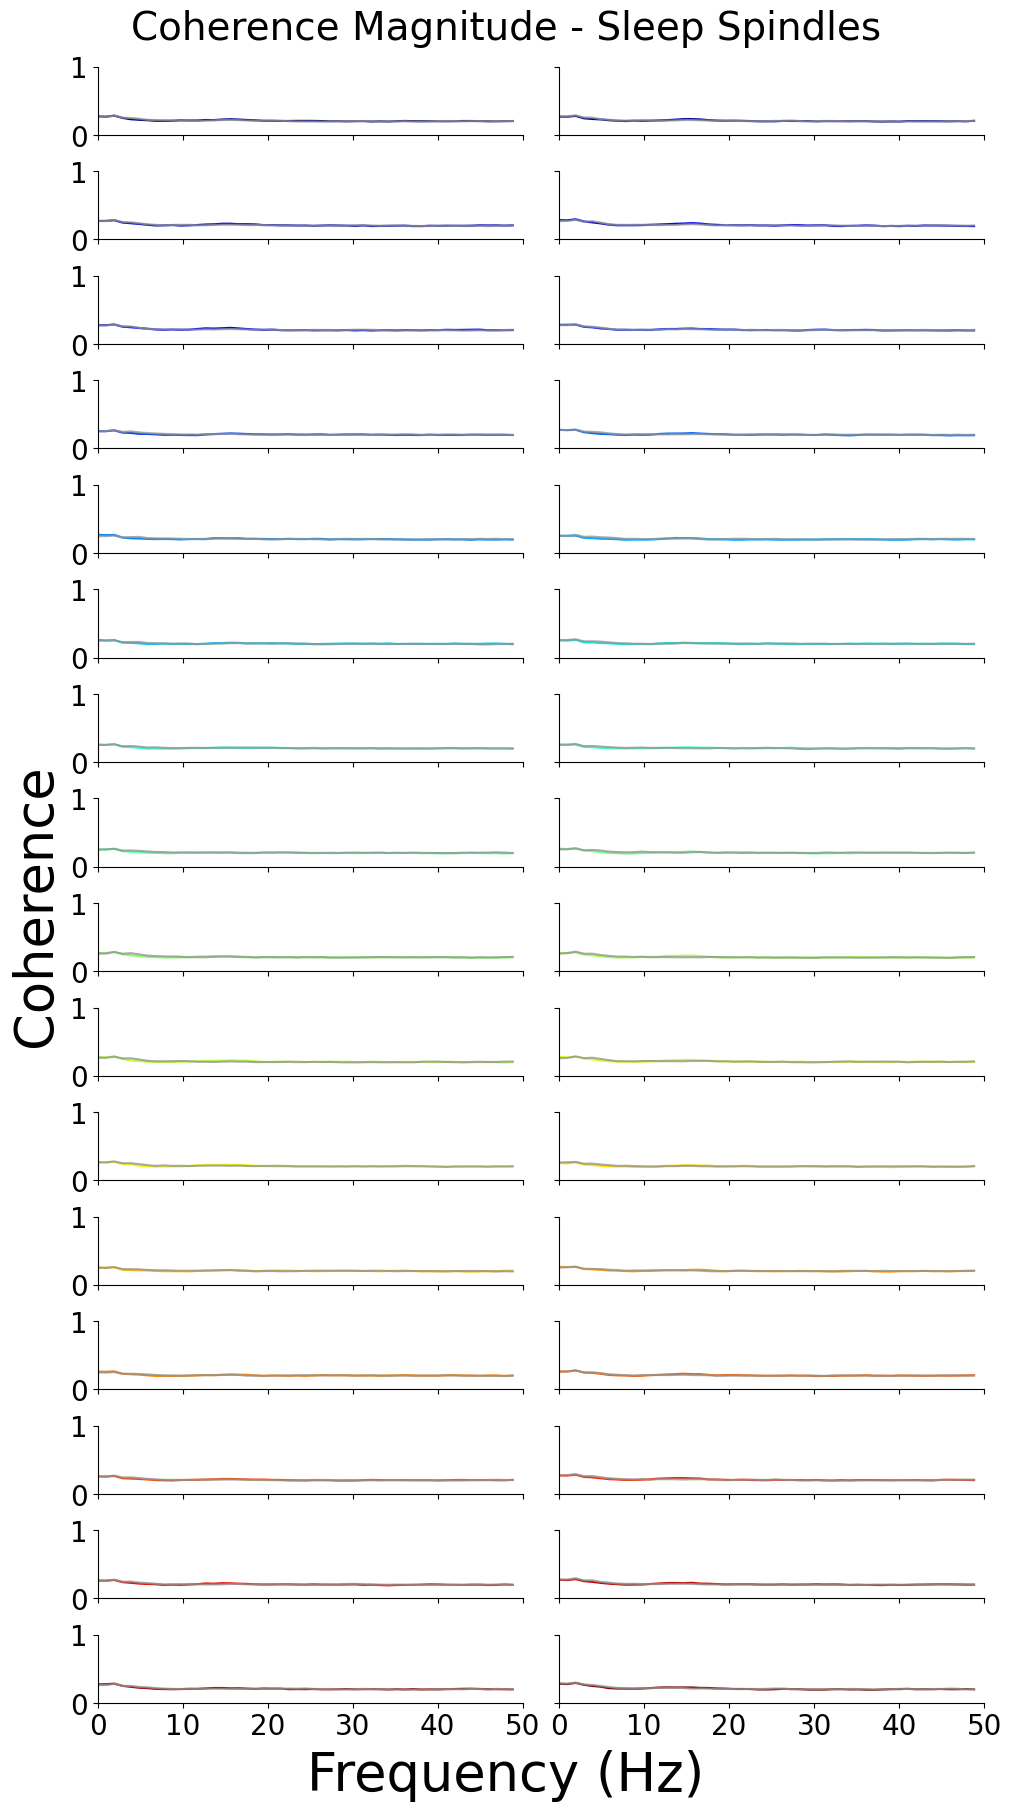

In [46]:
spi_freq_inds = np.where(
    (coh_dict["spi"]["frequency"][0] >= 10) & (coh_dict["spi"]["frequency"][0] <= 16)
)[0]
colors = plt.cm.jet(np.linspace(0, 1, len(depth_ordered_chs)))
mean_phase = []
fig1, axs1 = plt.subplots(
    nrows=16,
    ncols=2,
    figsize=(6, 20),
    # constrained_layout=True,
    subplot_kw={"polar": True},
)
fig1.subplots_adjust(wspace=0.001)
fig2, axs2 = plt.subplots(
    nrows=16,
    ncols=2,
    figsize=(10, 18),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
for ind, (ax1, ax2, ch) in enumerate(
    zip(axs1.ravel(), axs2.ravel(), stack_xr_dict["spi"].channel.values[2:])
):
    ax1.set_thetagrids(
        angles=[],
    )
    heights, bins, _ = ax1.hist(
        coh_dict["spi"]["phase"][:, 0, spi_freq_inds, 0, ind + 2].mean(axis=0),
        color=colors[ind],
        alpha=0.7,
        bins="fd",
    )
    ax1.axvline(
        np.mean(bins[np.argmax(heights) : np.argmax(heights) + 2]),
        color="red",
        ls="--",
    )
    mean_phase.append(np.mean(bins[np.argmax(heights) : np.argmax(heights) + 2]))
    heights, bins, _ = ax1.hist(
        coh_dict_null["spi"]["phase"][:, 0, spi_freq_inds, 0, ind + 2].mean(axis=0),
        color="#929591",
        alpha=0.3,
        bins="fd",
    )
    # phase = bins[np.argwhere(heights >= np.quantile(heights, 0.9)).flatten()].mean()
    # ax1.axvline(phase, color="red", ls="--")
    # mean_phase.append(phase)

    ax1.set_rticks([])
    ax1.set_ylabel(f"{int(ch):02d}")
    ax2.plot(
        coh_dict["spi"]["frequency"][0, :51],
        coh_dict["spi"]["coherence"][:, 0, :51, 0, ind + 2].mean(axis=0),
        color=colors[ind],
    )
    # ax3 = ax2.twinx()
    ax2.plot(
        coh_dict_null["spi"]["frequency"][0, :51],
        coh_dict_null["spi"]["coherence"][:, 0, :51, 0, ind + 2].mean(axis=0),
        color="#929591",
        alpha=0.8,
        ls="-",
    )
    # ax3.set_ylim([0, 0.05])
    ax2.spines[["top", "right"]].set_visible(False)
    ax2.set_ylim([0, 1])
    ax2.set_xlim([0, 50])
fig1.suptitle(
    f"Coherence Phase ({coh_dict["spi"]["frequency"][0,spi_freq_inds][0]:.02f}-{coh_dict["spi"]["frequency"][0, spi_freq_inds][-1]:.02f} Hz)\nsleep spindles",
    fontsize=14,
    y=0.93,
)
fig2.supylabel("Coherence")
fig2.supxlabel("Frequency (Hz)")
fig2.suptitle("Coherence Magnitude - Sleep Spindles")
axs1[0, 0].set_thetagrids(
    angles=[0, 90],
)
# fig1.tight_layout()

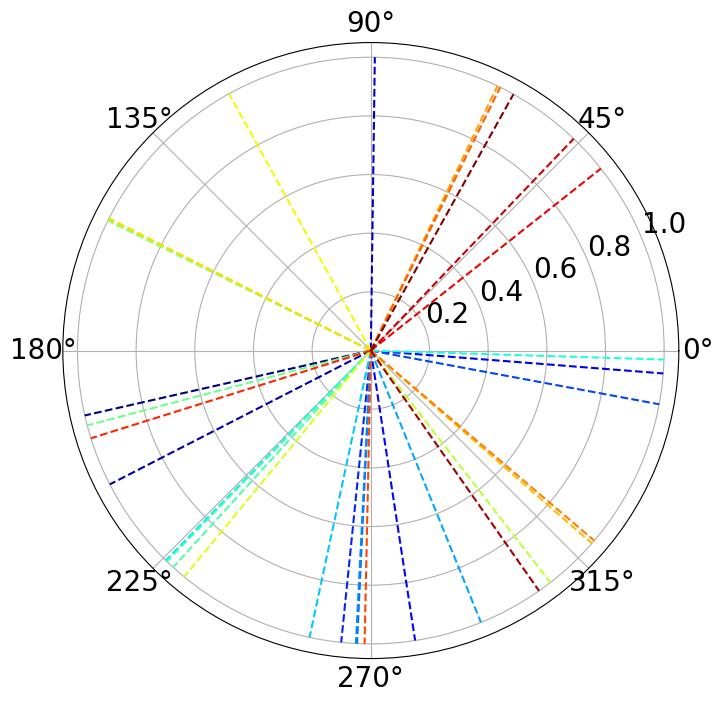

In [ ]:
# fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"polar": True})
# ax.set_prop_cycle("color", colors)
# for val1 in mean_phase:
#     ax.plot([0, val1], [0, 1], ls="--")

(<a list of 4 Line2D ticklines objects>,
 [Text(0.0, 0, '0°'), Text(1.5707963267948966, 0, '90°')])

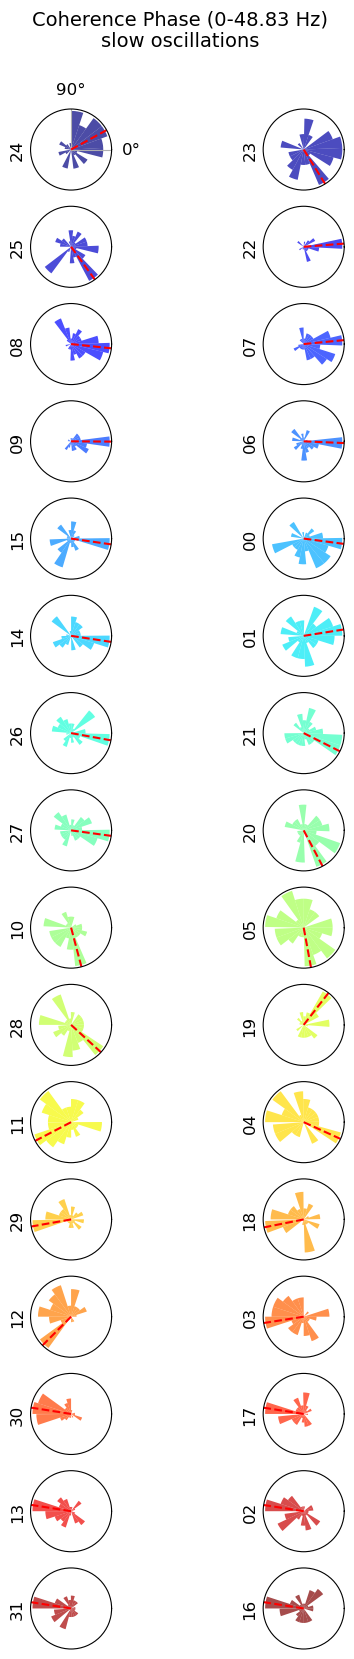

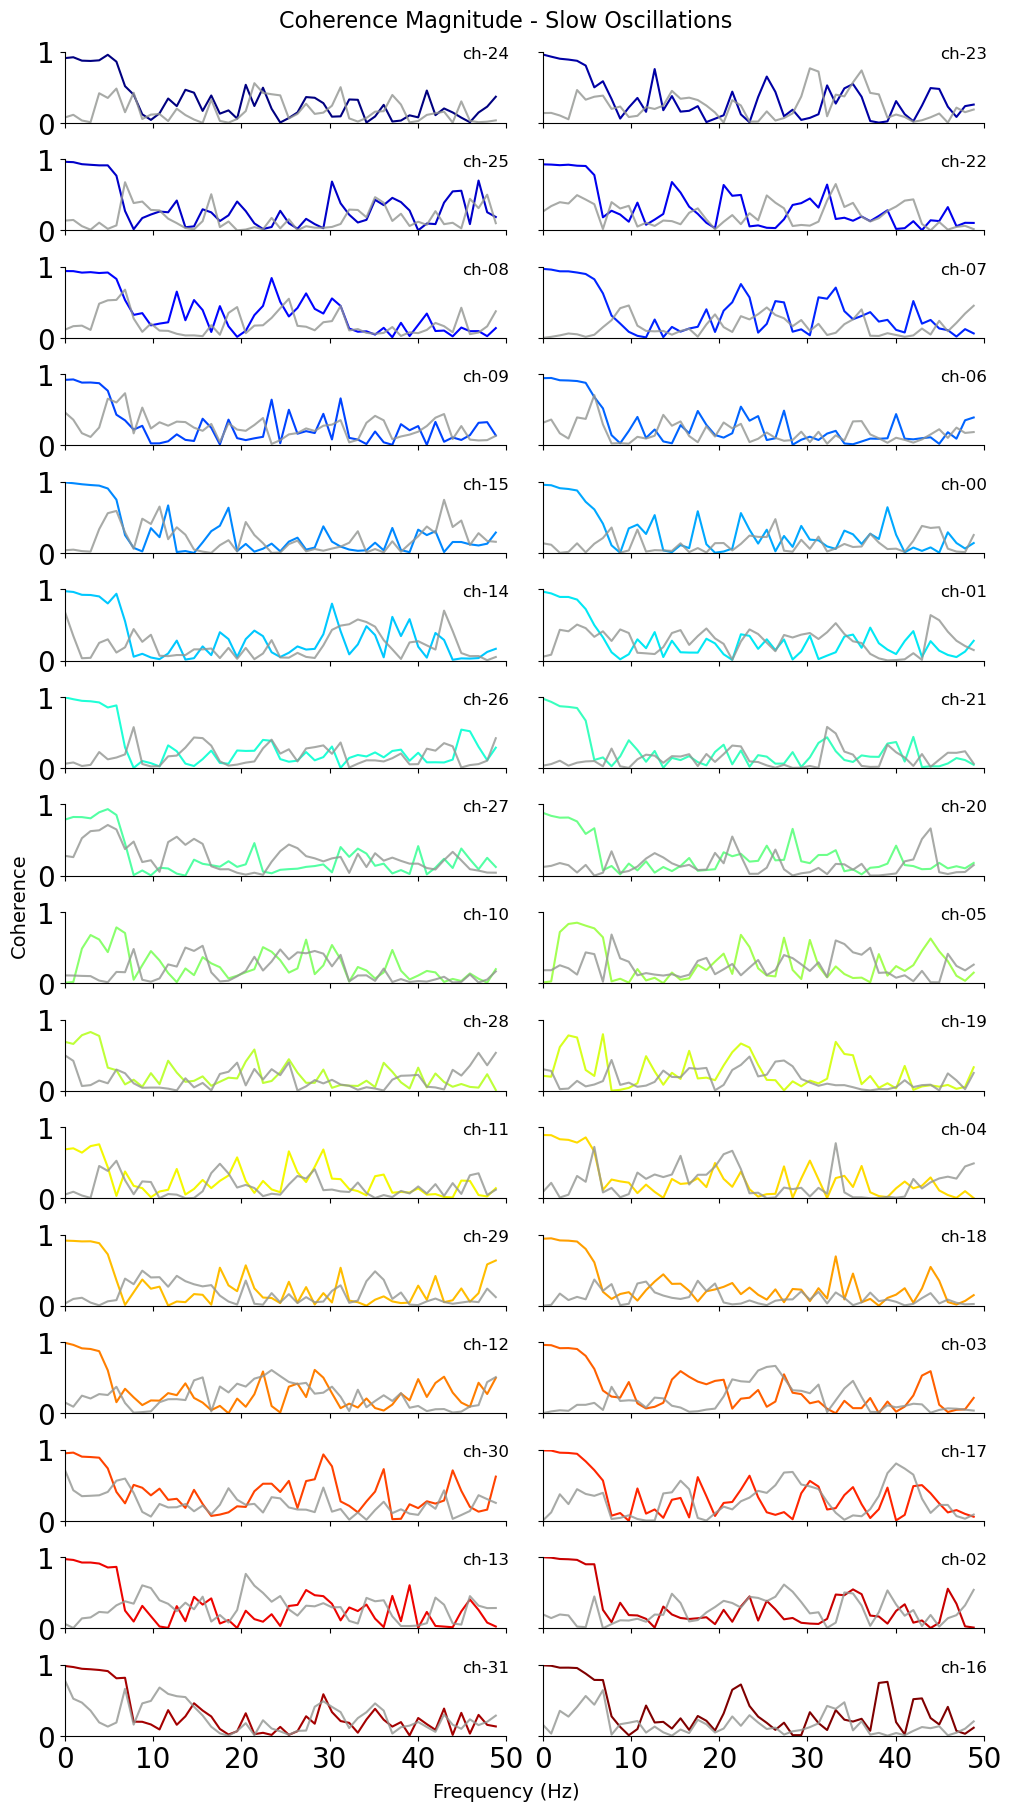

In [190]:
colors = plt.cm.jet(np.linspace(0, 1, len(depth_ordered_chs)))
mean_phase = []
fig1, axs1 = plt.subplots(
    nrows=16,
    ncols=2,
    figsize=(6, 20),
    # constrained_layout=True,
    subplot_kw={"polar": True},
)
fig1.subplots_adjust(wspace=0.001)
fig2, axs2 = plt.subplots(
    nrows=16,
    ncols=2,
    figsize=(10, 18),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
for ind, (ax1, ax2, ch) in enumerate(
    zip(axs1.ravel(), axs2.ravel(), stack_xr_dict["so"].channel.values[2:])
):
    ax1.set_thetagrids(
        angles=[],
    )
    heights, bins, _ = ax1.hist(
        coh_dict["so"]["phase"][0, :51, 0, ind + 2],
        color=colors[ind],
        alpha=0.7,
        bins=20,
    )
    # phase = bins[np.argwhere(heights >= np.quantile(heights, 0.9)).flatten()].mean()
    # ax1.axvline(phase, color="red", ls="--")
    # mean_phase.append(phase)
    ax1.axvline(
        np.mean(bins[np.argmax(heights) : np.argmax(heights) + 2]),
        color="red",
        ls="--",
    )
    mean_phase.append(np.mean(bins[np.argmax(heights) : np.argmax(heights) + 2]))
    ax1.set_rticks([])
    ax1.set_ylabel(f"{int(ch):02d}", fontsize=12)
    ax2.plot(
        coh_dict["so"]["frequency"][:51],
        coh_dict["so"]["coherence"][0, :51, 0, ind + 2],
        color=colors[ind],
        label=ch,
    )
    ax2.plot(
        coh_dict_null["so"]["frequency"][:51],
        coh_dict_null["so"]["coherence"][0, :51, 0, ind + 2],
        color="#929591",
        alpha=0.8,
        ls="-",
    )
    ax2.text(0.9, 0.9, f"ch-{int(ch):02d}", transform=ax2.transAxes, fontsize=12)
    ax2.spines[["top", "right"]].set_visible(False)
    ax2.set_ylim([0, 1])
    ax2.set_xlim([0, 50])
fig1.suptitle(
    f"Coherence Phase (0-{coh_dict["so"]["frequency"][:51][-1]:.02f} Hz)\nslow oscillations",
    fontsize=14,
    y=0.93,
)
fig2.supylabel("Coherence", fontsize=14)
fig2.supxlabel("Frequency (Hz)", fontsize=14)
fig2.suptitle("Coherence Magnitude - Slow Oscillations", fontsize=16)
axs1[0, 0].set_thetagrids(
    angles=[0, 90],
    fontsize=12,
)
# fig1.tight_layout()

/tmp/ipykernel_549079/3443227759.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig1.tight_layout()


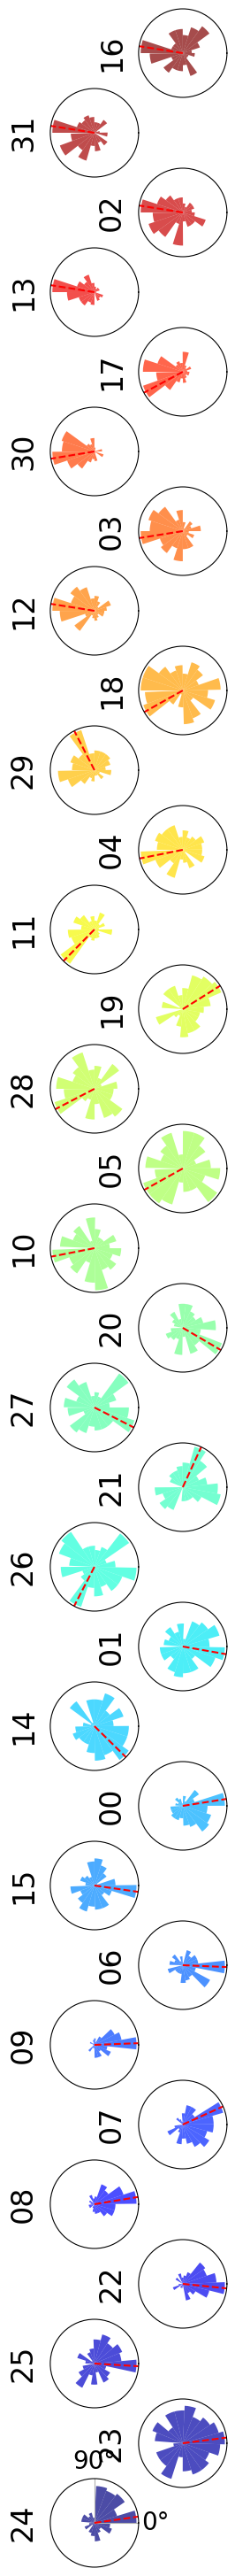

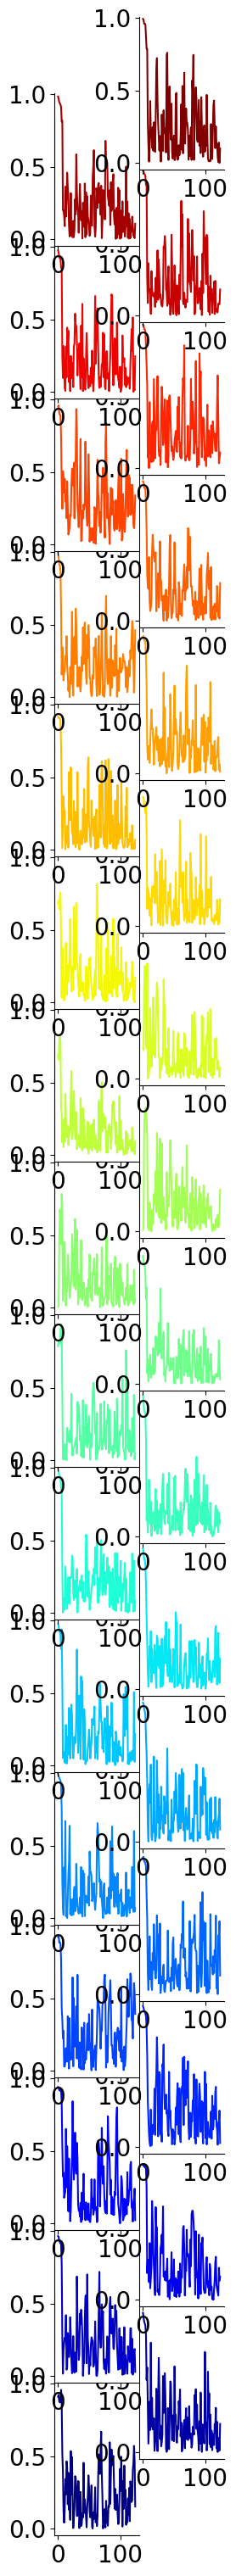

In [29]:
site_positions = []
for i in range(16):
    site_positions.append((0, i * 50))  # left column
    site_positions.append((25, i * 50 + 25))  # right column

site_positions = np.array(site_positions)

# Normalize for plotting layout
x_coords = site_positions[:, 0] / 25  # column index
y_coords = site_positions[:, 1] / 50

colors = plt.cm.jet(np.linspace(0, 1, len(depth_ordered_chs)))
mean_phase = []
fig1 = plt.figure(figsize=(10, 18))
fig2 = plt.figure(figsize=(10, 18))
all_axes = []
for ind, ch in enumerate(stack_xr_dict["spi"].channel.values[2:]):
    ax1 = fig1.add_axes(
        [
            0.1 + 0.1 * x_coords[ind],  # x position
            0.05 + 0.1 * y_coords[ind],  # y position
            0.1,
            0.1,
        ],
        polar=True,
    )
    ax2 = fig2.add_axes(
        [
            0.1 + 0.1 * x_coords[ind],  # x position
            0.05 + 0.1 * y_coords[ind],  # y position
            0.1,
            0.1,
        ],
        polar=False,
    )
    if ind == 0:
        ax1.set_thetagrids(
            angles=[0, 90],
        )
    else:
        ax1.set_thetagrids(
            angles=[],
        )
    heights, bins, _ = ax1.hist(
        coh_dict["so"]["phase"][0, :201, 0, ind + 2],
        color=colors[ind],
        alpha=0.7,
        bins=20,
    )
    # phase = bins[np.argwhere(heights > np.quantile(heights, 0.85)).flatten()].mean()
    # ax.axvline(phase, color="red", ls="--")
    ax1.axvline(
        np.mean(bins[np.argmax(heights) : np.argmax(heights) + 2]), color="red", ls="--"
    )
    mean_phase.append(np.mean(bins[np.argmax(heights) : np.argmax(heights) + 2]))
    ax1.set_rticks([])
    ax1.set_ylabel(f"{int(ch):02d}", labelpad=10)
    ax2.plot(
        coh_dict["so"]["frequency"][:201],
        coh_dict["so"]["coherence"][0, :201, 0, ind + 2],
        color=colors[ind],
    )
    ax2.spines[["top", "right"]].set_visible(False)
    all_axes.append(ax2)

# Link all to the first one
for ax in all_axes[1:]:
    ax.sharex(all_axes[0])
    ax.sharey(all_axes[0])

fig1.tight_layout()

In [193]:
from scipy import stats

In [266]:
freq_ind = 53
stats_dict = {}
for key in coh_dict.keys():
    stats_dict[key] = {}
    for ind, ch in enumerate(stack_xr_dict[key].channel.values[2:]):
        stats_dict[key][ch] = stats.ttest_ind_from_stats(
            mean1=coh_dict[key]["coherence"][:, :freq_ind, 0, ind + 2].mean(axis=0),
            std1=np.std(coh_dict[key]["coherence"][:, :freq_ind, 0, ind + 2], axis=0),
            nobs1=coh_dict[key]["coherence"].shape[0],
            mean2=coh_dict_null[key]["coherence"][:, :freq_ind, 0, ind + 2].mean(
                axis=0
            ),
            std2=np.std(
                coh_dict_null[key]["coherence"][:, :freq_ind, 0, ind + 2], axis=0
            ),
            nobs2=coh_dict_null[key]["coherence"].shape[0],
        )

In [265]:
coh_dict_null[key]["coherence"][:, :freq_ind, 0, ind + 2].shape

(2242, 53)

In [255]:
import statsmodels.api as sm

In [259]:
so_pvalues = np.array([ch_val.pvalue for ch_val in stats_dict["so"].values()])
spi_pvalues = np.array([ch_val.pvalue for ch_val in stats_dict["spi"].values()])

In [ ]:
sm.stats.multipletests(pvalues)

In [254]:
stats_dict["so"]["0"]

TtestResult(statistic=array([ 0.49025287,  0.66287773, -1.10268103, ..., -2.2682627 ,
       -3.02850182, -0.43313802]), pvalue=array([0.62498767, 0.50887537, 0.27271085, ..., 0.02537941, 0.00309969,
       0.6658115 ]), df=array([104., 104., 104., ..., 104., 104., 104.]))

Text(0.5, 0.01, 'Frequency (Hz)')

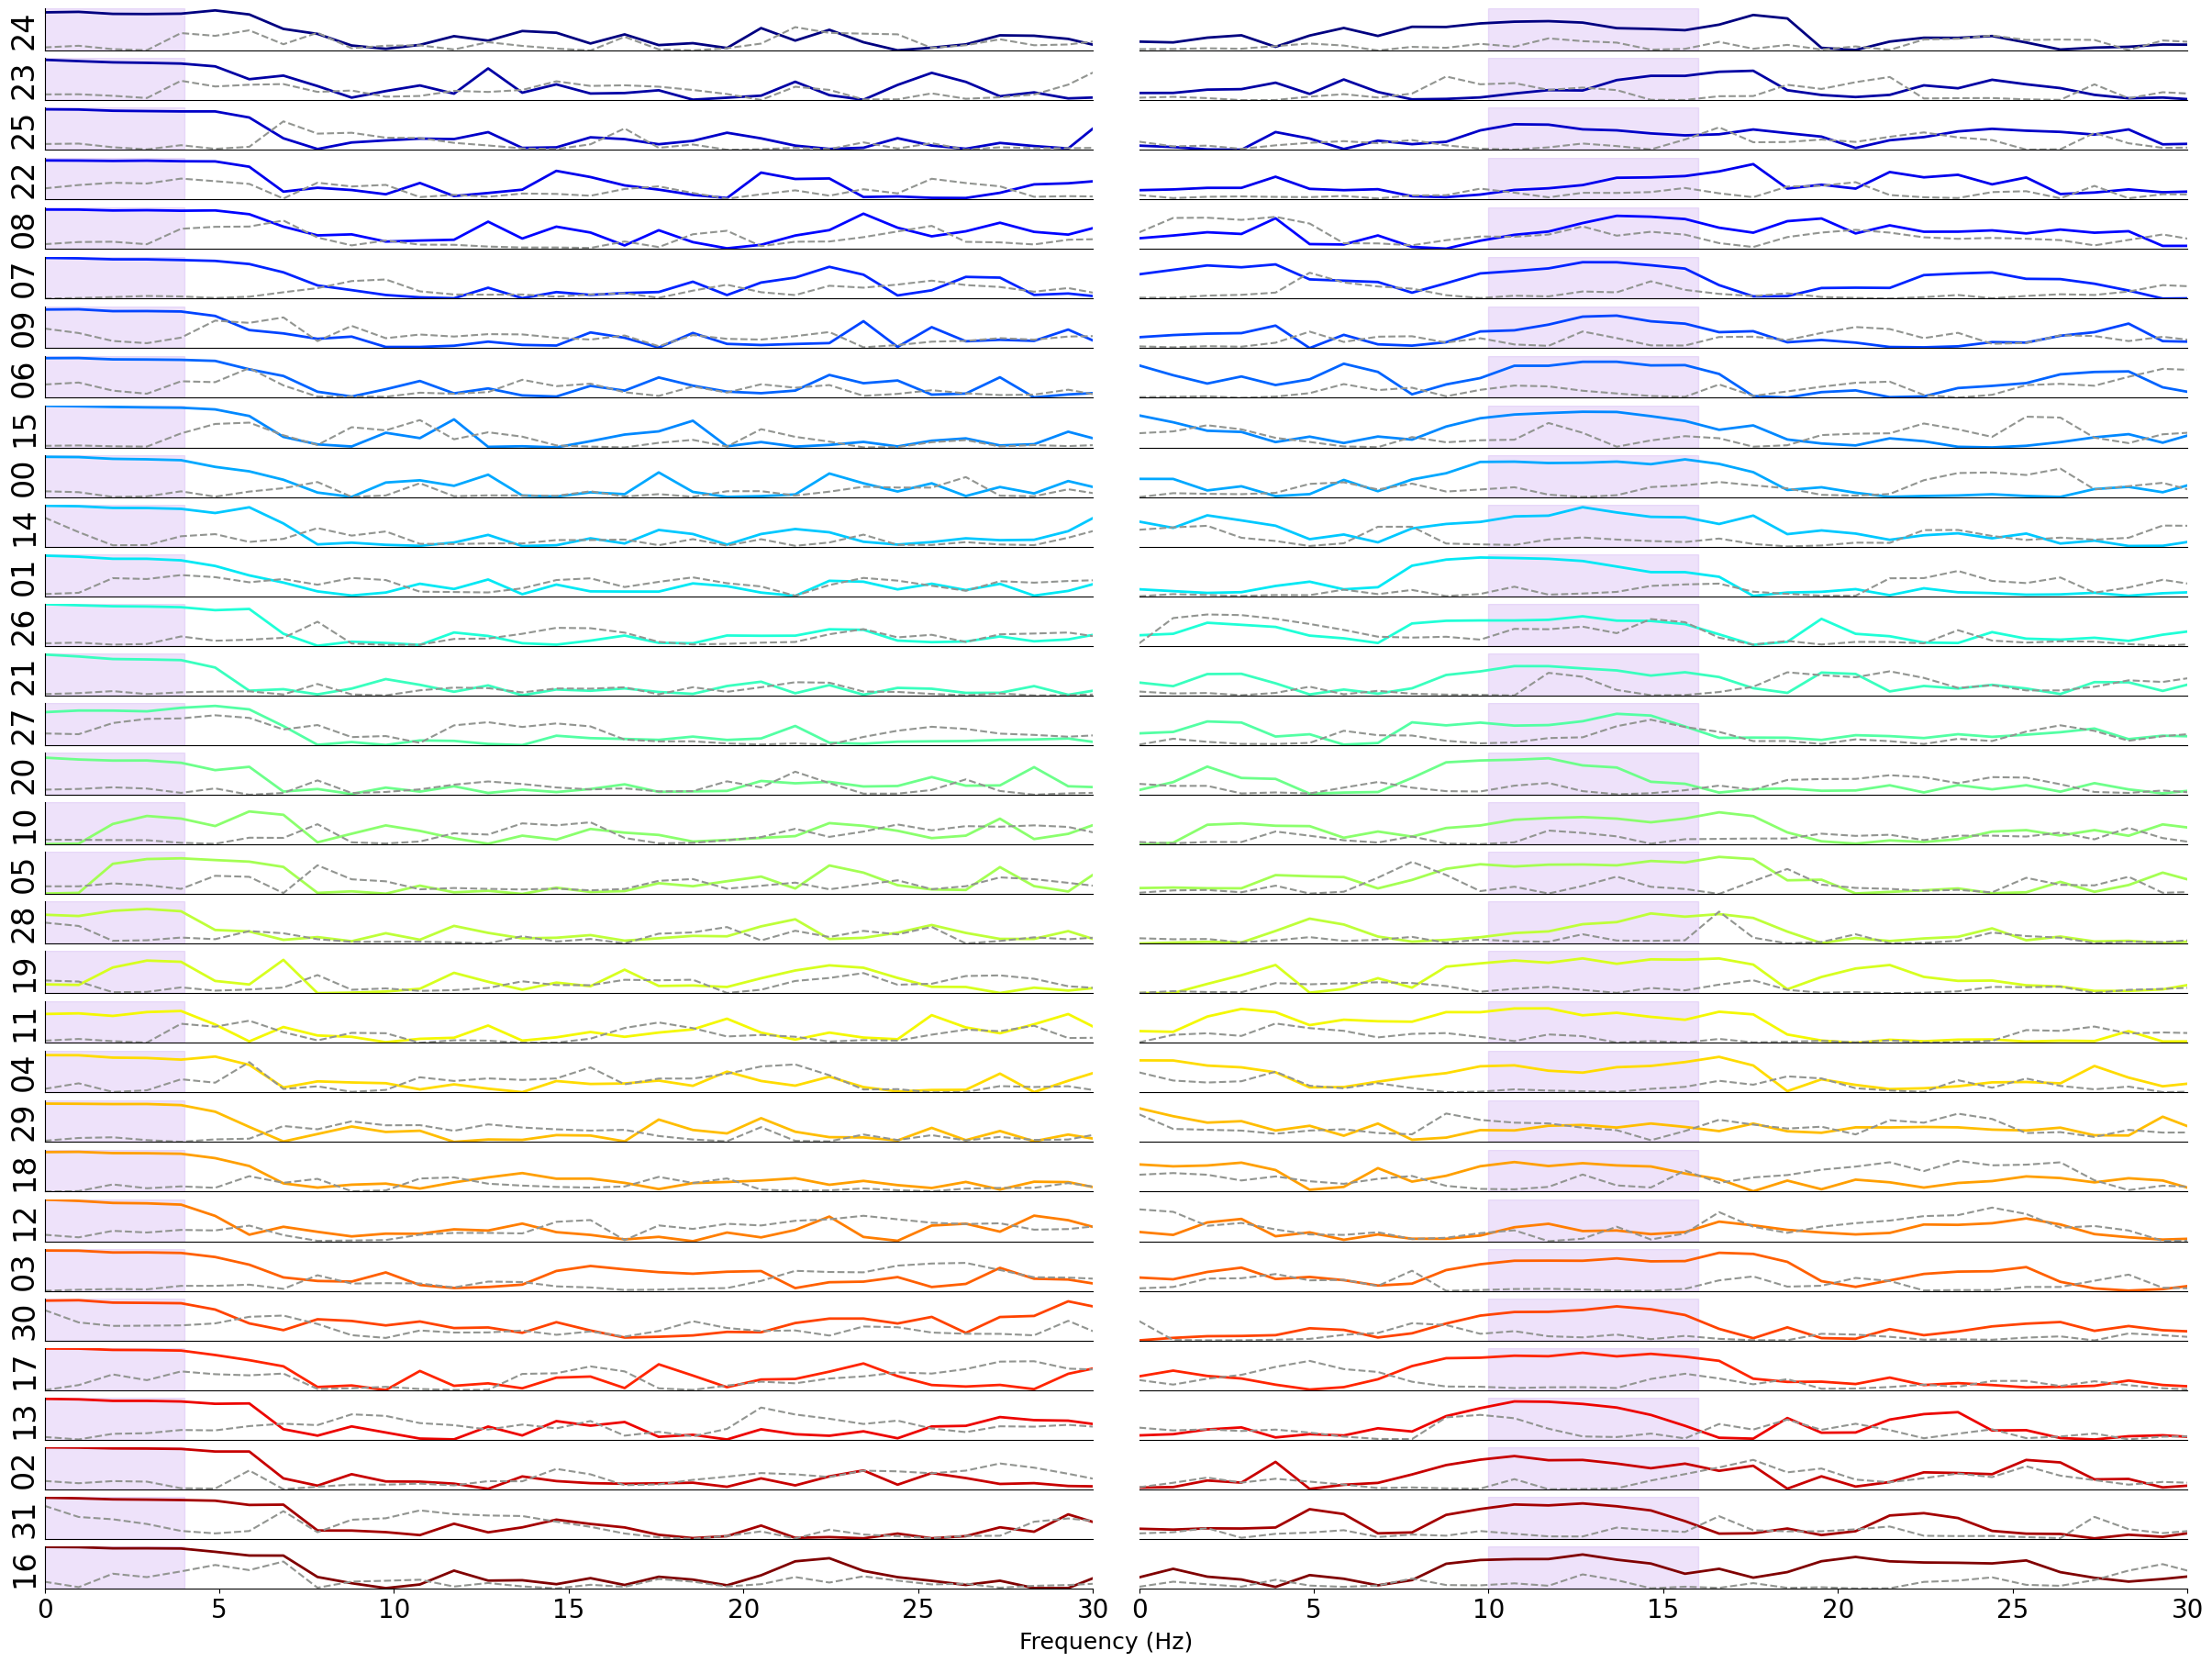

In [ ]:
fig, axs = plt.subplots(
    nrows=32,
    ncols=2,
    figsize=(24, 18),
    sharex=False,
    sharey=True,
    constrained_layout=True,
)
freq_ind = 53
colors = plt.cm.jet(np.linspace(0, 1, len(depth_ordered_chs)))
for ax_ind, (key, vals) in enumerate(coh_dict.items()):
    ax = axs[:, ax_ind]
    for ind, ch in enumerate(stack_xr_dict[key].channel.values[2:]):
        ax[ind].plot(
            vals["frequency"][:freq_ind],
            vals["coherence"][0, :freq_ind, 0, ind + 2],
            c=colors[ind],
            lw=2,
        )
        ax[ind].plot(
            coh_dict_null[key]["frequency"][:freq_ind],
            coh_dict_null[key]["coherence"][0, :freq_ind, 0, ind + 2],
            color="#929591",
            alpha=1,
            ls="--",
        )
        # ax[ind].plot(
        #     connectivity.frequencies[:201],
        #     vals["phase"][0, :201, 0, ind + 2]
        #     / vals["phase"][0, :201, 0, ind + 2].max(),
        #     c=colors[ind],
        #     ls="--",
        # )
        # if key == "so":
        #     ax[ind].axvspan(0, 4, alpha=0.3, color="#c79fef")
        # elif key == "spi":
        #     ax[ind].axvspan(10, 16, alpha=0.3, color="#c79fef")
        ax[ind].spines[["top", "right"]].set_visible(False)
        ax[ind].set_xlim([0, 30])  # vals["frequency"][:freq_ind][-1]])
        ax[ind].set_ylim([0, 1])
        axs[ind, 0].yaxis.set_tick_params(labelleft=False, left=False)
        axs[ind, 0].set_ylabel(f"{int(ch):02d}")
        if ind < len(axs[:, 0]) - 1:
            ax[ind].xaxis.set_tick_params(labelbottom=False, bottom=False)
            # ax[ind].spines[["bottom"]].set_visible(False)
for ax in axs[:, 1]:
    ax.spines[["left"]].set_visible(False)
    ax.yaxis.set_tick_params(labelleft=False, left=False)
fig.supxlabel("Frequency (Hz)", fontsize=18)

plotting
HYDO03
plotting
HYDO04


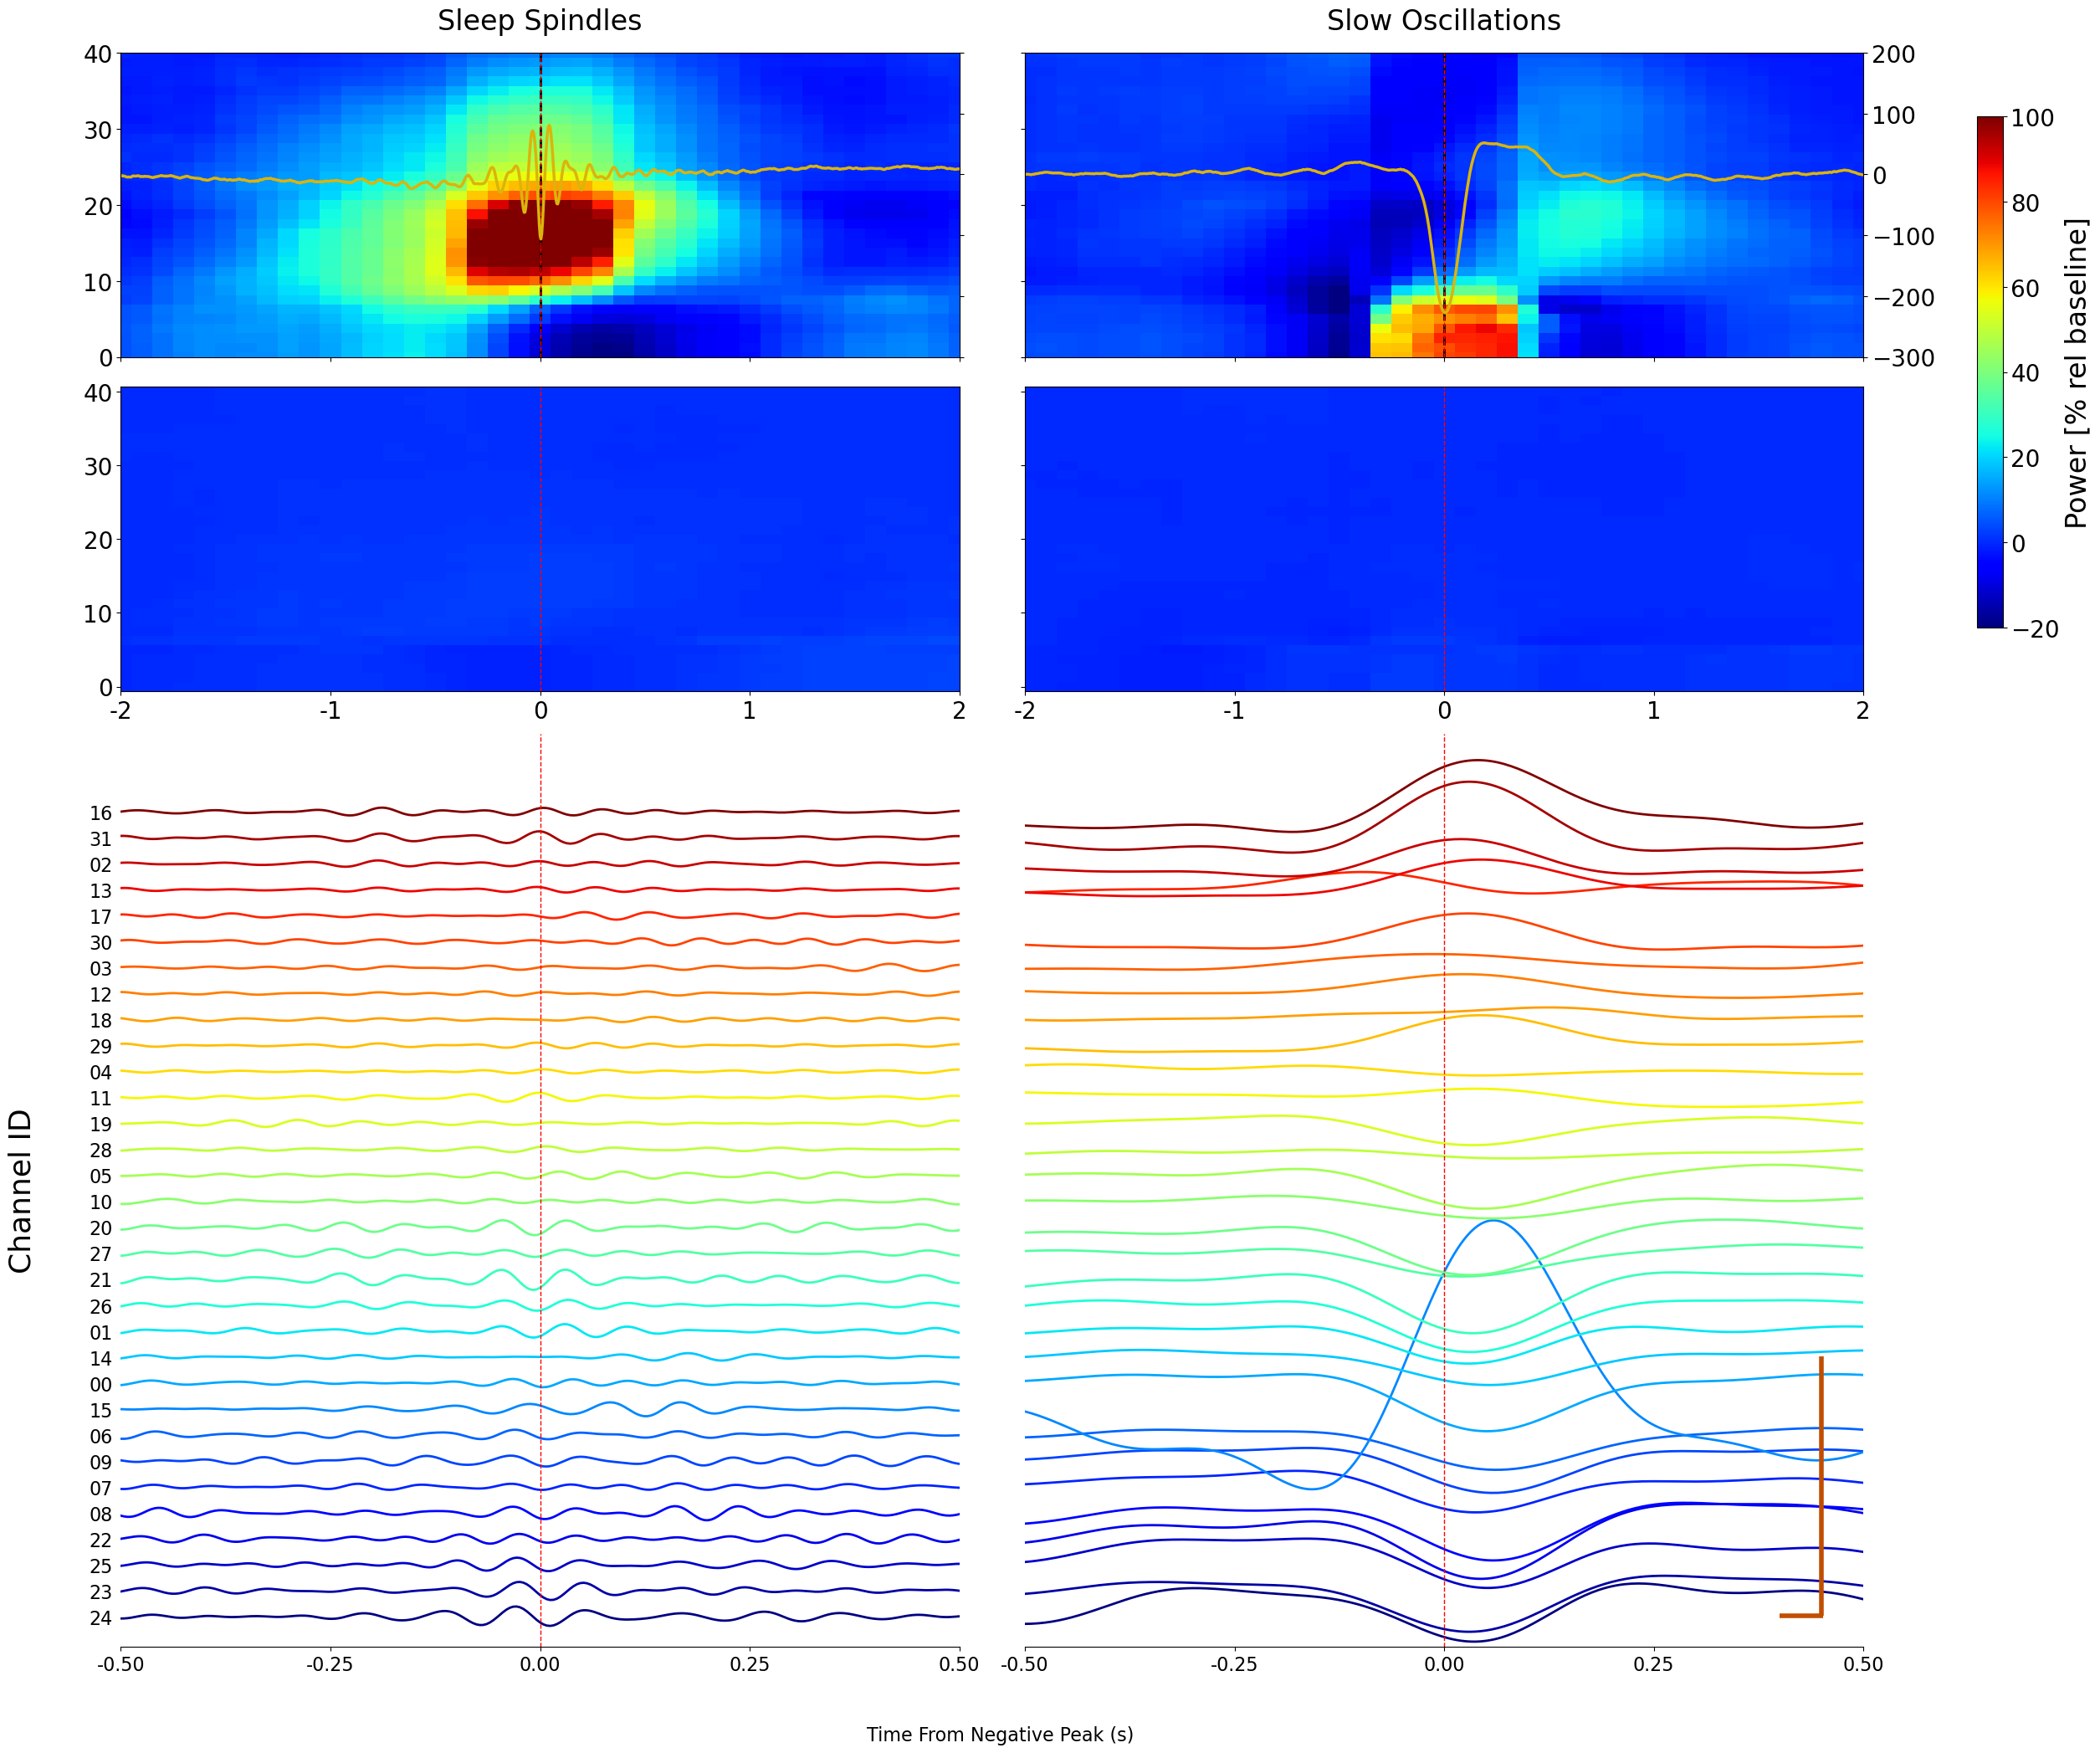

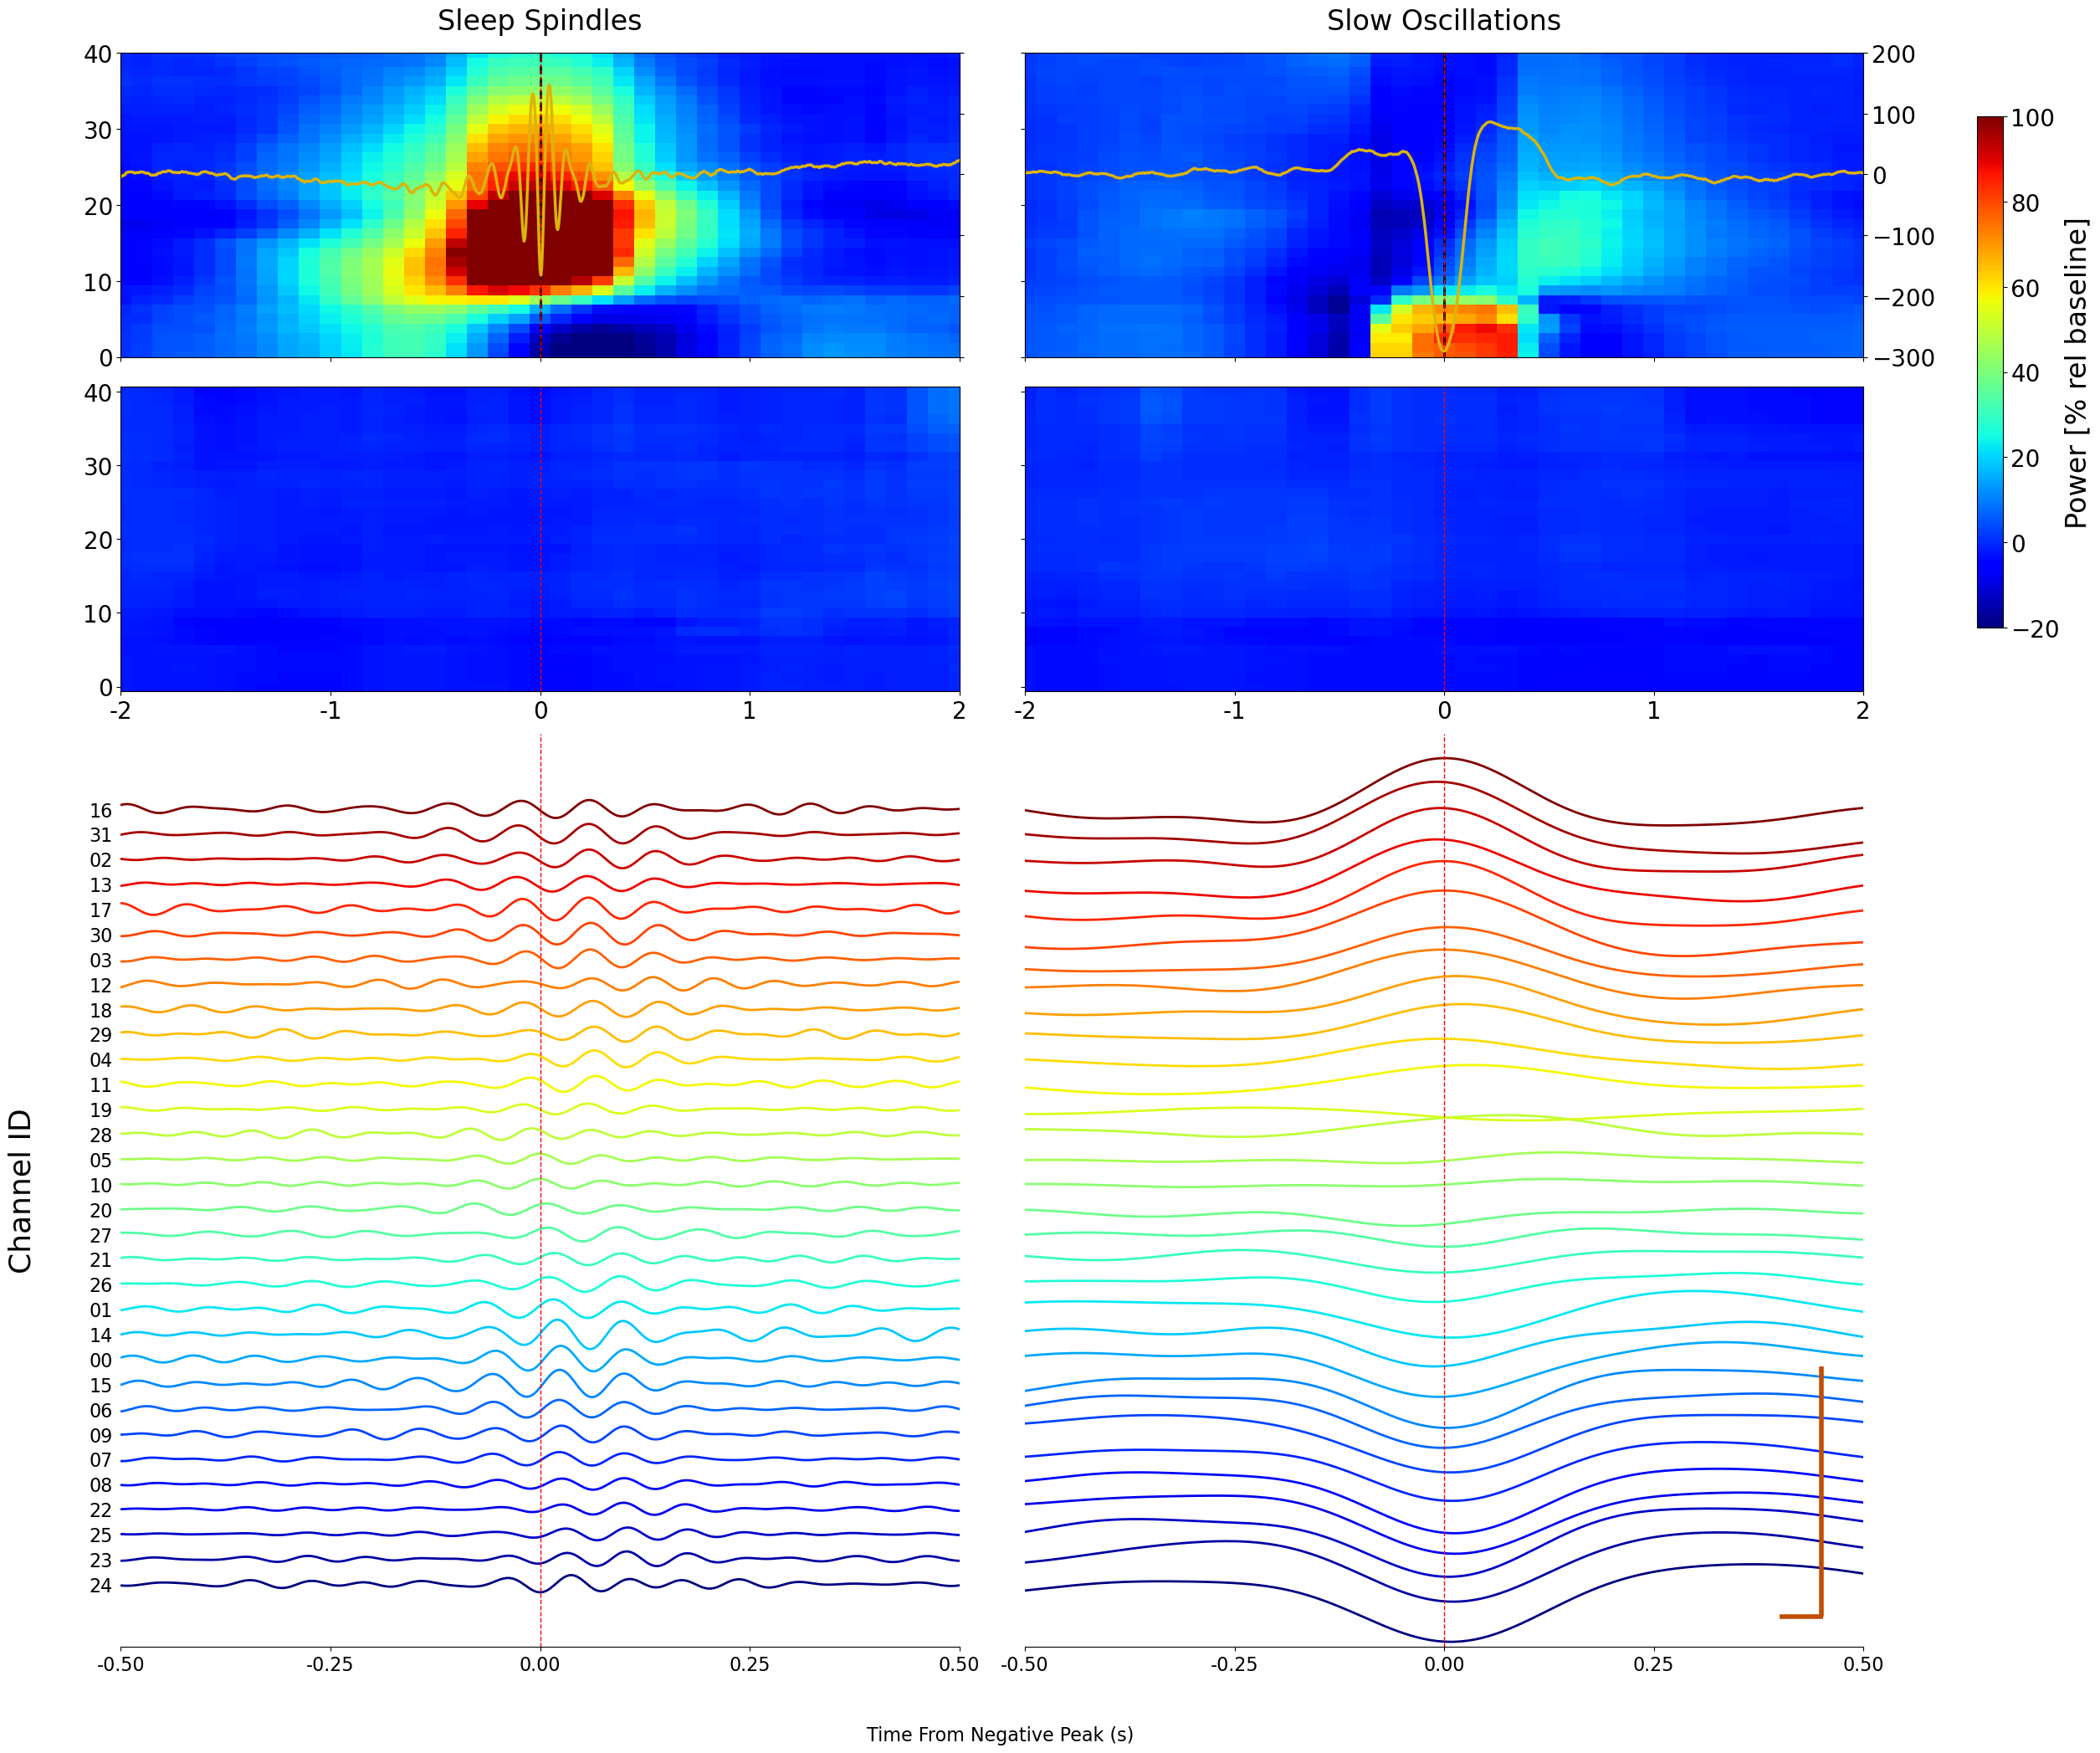

In [12]:
for animal in ["HYDO03", "HYDO04"]:
    spectra_window = 2
    plot_window = 0.5
    zero_ind = int(window * 250)
    win_ind = np.ceil(spectra_window * 250).astype(int)
    time_slice = slice(-2.1, 2.1)
    plot_slice = slice(-2.0, 2.0)
    freq_lims = slice(0, 40.1)
    scaler = 5
    vmin, vmax = -20, 100
    print("plotting")
    print(animal)
    depth_ordered_chs = si.depth_order(rec_dict[animal]["hyp"]["raw"]).get_channel_ids()
    colors = plt.cm.jet(np.linspace(0, 1, len(depth_ordered_chs)))
    depth_ordered_chs_ctx = np.append(
        depth_ordered_chs,
        list(spi_traces[animal]["ctx"].keys()),
    )
    tmp_time = (
        np.arange(np.round(spectra_window, 2) * 2 * 250 + 1)
        - (np.round(spectra_window, 2) * 250)
    ) / 250
    fig1, axs1 = plt.subplots(
        nrows=3,
        ncols=2,
        height_ratios=[3, 3, 9],
        figsize=(25, 20),
        constrained_layout=True,
        sharex="row",
        sharey="row",
    )
    region = "ctx"
    ax = axs1[0, :]
    ax0 = ax[0].twinx()
    ax1 = ax[1].twinx()
    ax1.sharey(ax0)
    channel = ["39"] if region == "ctx" else ["21", "16"]
    # tmp_data_spi = xr.concat(animal_xr_dict[animal]["spi-peak"]["ctx"], dim="epoch")
    # tmp_data_so = xr.concat(animal_xr_dict[animal]["so-peak"]["ctx"], dim="epoch")
    tmp_data_spi = animal_xr_dict[animal]["spi-peak"]["ctx"][1]
    tmp_data_so = animal_xr_dict[animal]["so-peak"]["ctx"][1]
    spectra_spi = xr_baseline_correction(tmp_data_spi, baseline_segment=slice(-4, -2))
    # spectra_spi = spectra_spi.mean(dim=("channel", "epoch"), skipna=True)
    spectra_spi = spectra_spi.mean(dim=("channel"), skipna=True)
    spectra_so = xr_baseline_correction(tmp_data_so, baseline_segment=slice(-4, -2))
    # spectra_so = spectra_so.mean(dim=("channel", "epoch"), skipna=True)
    spectra_so = spectra_so.mean(dim=("channel"), skipna=True)
    im = axs1[0, 0].pcolormesh(
        spectra_spi.sel(time=time_slice).time.values,
        spectra_spi.sel(freq=freq_lims).freq.values,
        spectra_spi.sel(freq=freq_lims, time=time_slice).T,
        cmap="jet",
        vmin=vmin,
        vmax=vmax,
    )
    im = axs1[0, 1].pcolormesh(
        spectra_so.sel(time=time_slice).time.values,
        spectra_so.sel(freq=freq_lims).freq.values,
        spectra_so.sel(freq=freq_lims, time=time_slice).T,
        cmap="jet",
        vmin=vmin,
        vmax=vmax,
    )
    # for filt_type, color in zip(
    #     [("raw", "raw"), ("so", "spi")], ["#029386", "#c04e01"]
    # ):
    for filt_type, color in zip([("raw", "raw")], ["#dbb40c"]):
        for ch in channel:
            label = "raw trace" if filt_type[0] == "raw" else "filtered trace"
            ax0.plot(
                tmp_time,
                spi_traces[animal][region][filt_type[1]][ch].mean(axis=0)[
                    zero_ind - win_ind : zero_ind + win_ind + 1
                ],
                label=label,
                lw=2.5,
                c=color,
            )
            ax1.plot(
                tmp_time,
                so_traces[animal][region][filt_type[0]][ch].mean(axis=0)[
                    zero_ind - win_ind : zero_ind + win_ind + 1
                ],
                label=label,
                lw=2.5,
                c=color,
            )
    ax[0].axvline(x=0, c="k", ls="--", lw=2)
    ax[1].axvline(x=0, c="k", ls="--", lw=2)
    ax[0].spines[["top", "right", "bottom"]].set_visible(False)
    ax[1].spines[["top", "right", "bottom"]].set_visible(False)
    ax[0].set_xlim([plot_slice.start, plot_slice.stop])
    ax[1].set_xlim([plot_slice.start, plot_slice.stop])
    ax[0].set_ylim([0, 40])
    ax[1].set_ylim([0, 40])
    ax0.set_ylim([-300, 200])
    ax1.set_ylim([-300, 200])
    ax[0].set_title("Sleep Spindles", fontsize=24, pad=20)
    ax[1].set_title("Slow Oscillations", fontsize=24, pad=20)
    ax0.yaxis.set_tick_params(labelright=False)
    # ax[0].set_ylabel("Amplitude ($\\mu$V)", fontsize=26, labelpad=10)  # x=-0.06)
    tmp_data_spi = xr.concat(animal_xr_dict[animal]["spi-peak"]["hyp"], dim="epoch")
    tmp_data_so = xr.concat(animal_xr_dict[animal]["so-peak"]["hyp"], dim="epoch")
    spectra_spi = xr_baseline_correction(tmp_data_spi, baseline_segment=slice(-4, -2))
    spectra_spi = spectra_spi.mean(dim=("channel", "epoch"), skipna=True)
    spectra_so = xr_baseline_correction(tmp_data_so, baseline_segment=slice(-4, -2))
    spectra_so = spectra_so.mean(dim=("channel", "epoch"), skipna=True)
    axs1[1, 0].sharex(axs1[0, 0])
    # axs1[1, 1].sharex(axs1[0, 0])
    im = axs1[1, 0].pcolormesh(
        spectra_spi.sel(time=time_slice).time.values,
        spectra_spi.sel(freq=freq_lims).freq.values,
        spectra_spi.sel(freq=freq_lims, time=time_slice).T,
        cmap="jet",
        vmin=vmin,
        vmax=vmax,
    )
    im = axs1[1, 1].pcolormesh(
        spectra_so.sel(time=time_slice).time.values,
        spectra_so.sel(freq=freq_lims).freq.values,
        spectra_so.sel(freq=freq_lims, time=time_slice).T,
        cmap="jet",
        vmin=vmin,
        vmax=vmax,
    )
    fig1.colorbar(
        im,
        ax=axs1[:2, 1].ravel().tolist(),
        label="Power [% rel baseline]",
        shrink=0.8,
    )
    for ax in axs1[1, :].ravel():
        _ = ax.set_xticks(
            ticks=np.arange(-spectra_window, spectra_window + 0.01, 1.0),
            labels=[
                f"{int(x):d}"
                for x in np.arange(-spectra_window, spectra_window + 0.01, 1.0)
            ],
            # rotation=45,
        )
    for ax in axs1[0, :].ravel():
        _ = ax.xaxis.set_tick_params(labelbottom=False)

    y_tick_labels = []
    tmp_time = (
        np.arange(np.round(plot_window, 2) * 2 * 250 + 1)
        - (np.round(plot_window, 2) * 250)
    ) / 250
    win_ind = np.ceil(plot_window * 250).astype(int)
    axs1[2, 0].set_prop_cycle("color", colors)
    axs1[2, 1].set_prop_cycle("color", colors)
    for ind, ch in enumerate(depth_ordered_chs):
        if int(ch) <= 32:
            region = "hyp"
            ls = "-"
        else:
            region = "ctx"
            ls = "-"
        tmp_trace_spi = spi_traces[animal][region]["spi"][ch]
        tmp_trace_so = so_traces[animal][region]["so"][ch]
        axs1[2, 0].plot(
            tmp_time,
            (tmp_trace_spi.T.mean(axis=1)[zero_ind - win_ind : zero_ind + win_ind + 1])
            + (scaler * ind),
            # c=color,
            lw=2,
            ls=ls,
        )
        axs1[2, 1].plot(
            tmp_time,
            (tmp_trace_so.T.mean(axis=1)[zero_ind - win_ind : zero_ind + win_ind + 1])
            + (scaler * ind),
            # c=color,
            lw=2,
            ls=ls,
        )

        y_tick_labels.append(
            f"{int(ch):02d}"  # ({rec_dict[animal][region].id_to_index(ch) +1:02d})"
        )
    min_spi_y = (
        spi_traces[animal]["hyp"]["spi"][depth_ordered_chs[0]]
        .T.mean(axis=1)[zero_ind - win_ind : zero_ind + win_ind + 1]
        .min()
    )
    min_so_y = (
        so_traces[animal]["hyp"]["so"][depth_ordered_chs[0]]
        .T.mean(axis=1)[zero_ind - win_ind : zero_ind + win_ind + 1]
        .min()
    )
    min_y = min(min_spi_y, min_so_y)
    for a1 in axs1.flatten():
        a1.axvline(x=0, color="r", lw=1, ls="--")
    axs1[2, 1].vlines(x=0.45, ymin=min_y + 5, ymax=min_y + 55, colors="#c04e01", lw=4)
    axs1[2, 1].hlines(y=min_y + 5, xmin=0.4, xmax=0.452, colors="#c04e01", lw=4)

    _ = axs1[2, 0].set_yticks(
        ticks=np.arange(0, len(y_tick_labels) * scaler, scaler),
        labels=y_tick_labels,
    )

    axs1[2, 0].set_ylabel(
        "Channel ID",
        fontsize=26,
        labelpad=45,
    )
    fig1.supxlabel("Time From Negative Peak (s)                 ", fontsize=16, y=-0.04)

    axs1[2, 0].yaxis.set_tick_params(
        bottom=False, labelbottom=True, which="major", labelsize=16
    )
    axs1[2, 0].xaxis.set_tick_params(
        bottom=True, labelbottom=True, which="major", labelsize=16
    )

    axs1[2, 1].yaxis.set_tick_params(
        bottom=False, labelbottom=False, which="major", labelsize=16
    )
    axs1[2, 1].xaxis.set_tick_params(
        bottom=True, labelbottom=True, which="major", labelsize=16
    )

    axs1[2, 0].set_xlim([-0.5, 0.5])
    axs1[2, 0].set_ylim([min_y - 1, (len(depth_ordered_chs) * scaler) + scaler])
    axs1[2, 1].set_xlim([-0.5, 0.5])
    axs1[2, 1].set_ylim([min_y - 1, (len(depth_ordered_chs) * scaler) + 10])
    axs1[2, 0].set_xticks(
        [-0.5, -0.25, 0, 0.25, 0.5], labels=["-0.50", "-0.25", "0.00", "0.25", "0.50"]
    )
    axs1[2, 1].set_xticks(
        [-0.5, -0.25, 0, 0.25, 0.5], labels=["-0.50", "-0.25", "0.00", "0.25", "0.50"]
    )
    axs1[2, 0].spines[
        [
            "right",
            "left",
            "top",
        ]
    ].set_visible(False)
    axs1[2, 1].spines[
        [
            "right",
            "left",
            "top",
        ]
    ].set_visible(False)
    # fig1.tight_layout()
    fig1.savefig(
        Path(
            "/gpfs01/born/animal/DanielG/hypo_sleep/figures/",
            f"{animal}_ch_traces_fig_1.png",
        ),
        dpi=500,
        facecolor="white",
        transparent=False,
        bbox_inches="tight",
    )

In [ ]:
for ch in depth_ordered_chs